In [1]:
from eddy import rotationmap
import bettermoments as bm
from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.nddata import Cutout2D
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import matplotlib.font_manager as fm

In [2]:
ALMAData = fits.open('PDS277/member.uid___A001_X158f_Xb8.PDS277_sci.spw25.cube.I.pbcor.fits')
cube = SpectralCube.read(ALMAData)
print(cube)

SpectralCube with shape=(3837, 512, 512) and unit=Jy / beam:
 n_x:    512  type_x: RA---SIN  unit_x: deg    range:   125.791868 deg:  125.806871 deg
 n_y:    512  type_y: DEC--SIN  unit_y: deg    range:   -39.122883 deg:  -39.111244 deg
 n_s:   3837  type_s: FREQ      unit_s: Hz     range: 229597263891.500 Hz:231470396501.240 Hz


In [16]:
sub_cube_slab = cube.spectral_slab(2.30535e+11 *u.Hz, 2.30539e+11 *u.Hz)
'''
lat_range = [-39.1173835,-39.1167661] * u.deg
lon_range = [125.7990542,125.7997978] * u.deg

sub_cube_slab = cube.subcube(xlo = lon_range[0],xhi=lon_range[1],ylo=lat_range[0],yhi=lat_range[1])


subcubearray = np.array(sub_cube_slab)
'''


'\nlat_range = [-39.1173835,-39.1167661] * u.deg\nlon_range = [125.7990542,125.7997978] * u.deg\n\nsub_cube_slab = cube.subcube(xlo = lon_range[0],xhi=lon_range[1],ylo=lat_range[0],yhi=lat_range[1])\n\n\nsubcubearray = np.array(sub_cube_slab)\n'

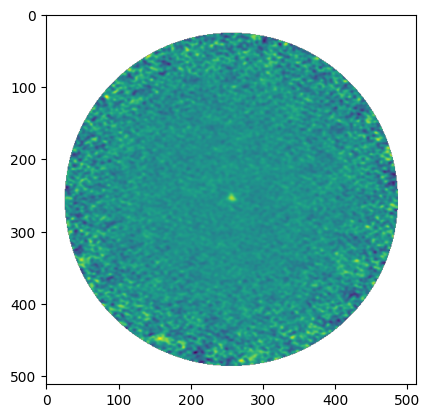

In [17]:
sub_cube_slab[6,:,:].quicklook()

In [18]:
sub_cube_slab.write('PDS277/PDS277SubCube.fits', format='fits',overwrite=True)

In [52]:
data, velax = bm.load_cube('PDS277/PDS277SubCube.fits')

smoothed_data = bm.smooth_data(data=data,smooth=5,polyorder=1)
rms = bm.estimate_RMS(data=data, N=1)
rms_smoothed = bm.estimate_RMS(data=smoothed_data, N=1)

print('RMS = {:.1f} mJy/beam (original)'.format(rms * 1e3))
print('RMS = {:.1f} mJy/beam (smoothed)'.format(rms_smoothed * 1e3))

RMS = 6.9 mJy/beam (original)
RMS = 4.4 mJy/beam (smoothed)


In [53]:
user_mask = bm.get_user_mask(data=data, user_mask_path=None)

threshold_mask=bm.get_threshold_mask(data=data,
                                    clip=3,
                                    smooth_threshold_mask=0.5)

channel_mask = bm.get_channel_mask(data=data,
                                   firstchannel=0,
                                   lastchannel=-1)

mask = bm.get_combined_mask(user_mask=user_mask,
                            threshold_mask=threshold_mask,
                            channel_mask=channel_mask,
                            combine='and')
masked_data = data * mask

bm.available_collapse_methods()

Available methods are:

	 zeroth       (integrated intensity)
	 first        (intensity weighted average velocity)
	 second       (intensity weighted velocity dispersion)
	 eighth       (peak intensity)
	 ninth        (velocity channel of peak intensity)
	 maximum      (both collapse_eighth and collapse_ninth)
	 quadratic    (quadratic fit to peak intensity)
	 width        (effective width for a Gaussian profile)
	 percentiles  (intesity weighted percentiles)
	 gaussian     (gaussian fit)
	 gaussthick   (gaussian with optically thick core fit)
	 gausshermite (gaussian-hermite expansion fit)
	 doublegauss  (double gaussian fit)

Call the function with `collapse_{method_name}`.


In [54]:
moments = bm.collapse_first(velax=velax, data=data, rms=rms)

In [55]:
bm.save_to_FITS(moments=moments, method='first', path='PDS277/PDS277SubCube.fits')

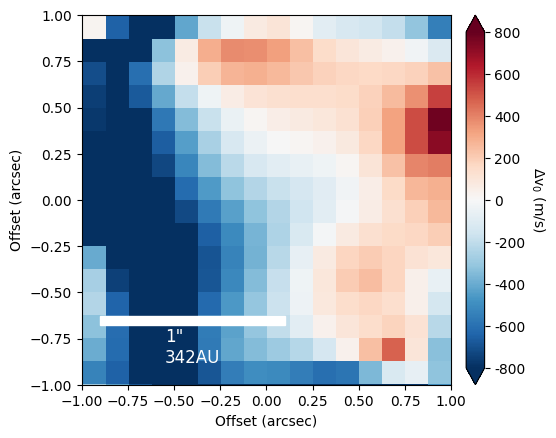

In [64]:
momentone = fits.open('PDS277/PDS277SubCube_M1.fits')[0].data
imgsize=600
momentone = np.array(Cutout2D(momentone,
                                (len(momentone[0])/2,len(momentone)/2),
                                (imgsize,imgsize)).data)
fig,ax = plt.subplots(1,1) 


im = ax.imshow(momentone-1800,
          cmap='RdBu_r',
          extent=[0.1062*imgsize/2,-0.1062*imgsize/2,-0.1062*imgsize/2,0.1062*imgsize/2],origin='lower',
               vmin=-800,vmax=800,
               zorder=-9)
cb = plt.colorbar(im, pad=0.03, extend='both', format='%.0f')
cb.set_label(r'$\Delta$v$_0$ (m/s)',
                     rotation=270, labelpad=15)

scalebar = AnchoredSizeBar(ax.transData,
                           1, '1"\n342AU', 'lower left', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=0.05,
                           fontproperties=fontprops
                           )
ax.add_artist(scalebar)
ax.invert_xaxis()

plt.xlim(-1,1) 
plt.ylim(-1,1)

ax.set_xlabel('Offset (arcsec)')
ax.set_ylabel('Offset (arcsec)')
#plt.savefig('EnvironMoment1.pdf',bbox_inches='tight')

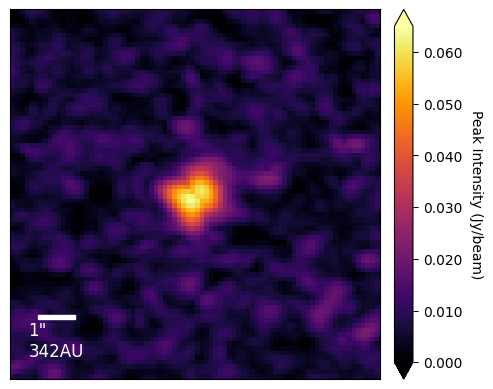

In [3]:
import matplotlib.font_manager as fm
fontprops = fm.FontProperties(size=12)

imgsize=600

momenteight = fits.open('PDS277/PDS277SubCube_M8.fits')[0].data
momenteight = np.array(Cutout2D(momenteight,
                                (len(momenteight[0])/2,len(momenteight)/2),
                                (imgsize,imgsize)).data)
fig,ax = plt.subplots(1,1) 


im = ax.imshow(momenteight,
          cmap='inferno',
               vmin=0,vmax=0.065,
          extent=[0.1062*imgsize/2,-0.1062*imgsize/2,-0.1062*imgsize/2,0.1062*imgsize/2],origin='lower',zorder=-9)
cb = plt.colorbar(im, pad=0.03, extend='both', format='%.3f')
cb.set_label(r'Peak Intensity (Jy/beam)',
                     rotation=270, labelpad=15)

scalebar = AnchoredSizeBar(ax.transData,
                           1, '1"\n342AU', 'lower left', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=0.1,
                           fontproperties=fontprops
                           )

ax.tick_params(
        axis='both',          # changes apply to both axes
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False, 
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False)

ax.add_artist(scalebar)
ax.invert_xaxis()
plt.xlim(-5,5) 
plt.ylim(-5,5)

#ax.set_xlabel('Offset (arcsec)')
#ax.set_ylabel('Offset (arcsec)')
plt.savefig('PDS277Moment8.pdf',bbox_inches='tight')